# Graph-ARI Complete Walkthrough

This notebook shows how to use the `graphari` package end to end:

- discover the bundled data
- build single and multiple dynamic weekly graphs
- inspect graph, node, and edge attributes
- extract the node feature matrix and COO edge index
- load the feature tables directly
- build graphs with a custom feature subset
- visualize dynamic municipality creation, time series, and local network structure


In [141]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import graphari as ga

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

focus_week = '2024/34'
focus_node = '24059'
stable_node = '24028'
window_start = '2024/01'
window_end = '2024/52'


## 1. Discover The Bundled Data

Use the package helpers to list the available weekly tables and epidemiological weeks.

In [142]:
available_tables = ga.available_feature_tables()
available_weeks = ga.available_epiweeks()

print(f'Available feature tables: {available_tables}')
print(f'Number of epidemiological weeks: {len(available_weeks)}')
print(f'First 5 weeks: {available_weeks[:5]}')
print(f'Last 5 weeks: {available_weeks[-5:]}')

Available feature tables: ['10m_wind_speed.csv', '2m_mean_dewpoint_temperature.csv', '2m_mean_temperature.csv', '2m_relative_humidity.csv', 'mortality_rates.csv', 'total_precipitation.csv']
Number of epidemiological weeks: 1148
First 5 weeks: ['2003/01', '2003/02', '2003/03', '2003/04', '2003/05']
Last 5 weeks: ['2024/48', '2024/49', '2024/50', '2024/51', '2024/52']


## 2. Build Dynamic Weekly Graphs

`build_graph` creates one weekly graph. `build_graphs` creates a dictionary of graphs over a period.

These graphs are dynamic: municipalities are omitted until their creation week, rather than being kept in the graph with a false flag only.

In [143]:
G = ga.build_graph(week=focus_week)
graphs_window = ga.build_graphs(start_week=window_start, end_week=window_end)

print(f'Graph for {focus_week}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Graphs built in window: {len(graphs_window)}')
print(f'Weeks in window: {list(graphs_window)[:3]} ... {list(graphs_window)[-3:]}')

Graph for 2024/34: 2476 nodes, 7198 edges
Graphs built in window: 52
Weeks in window: ['2024/01', '2024/02', '2024/03'] ... ['2024/50', '2024/51', '2024/52']


## 3. Inspect Graph-Level Metadata

The graph metadata tells you which variables are exogenous, endogenous, static, and which features are used in the node feature matrix.

In [144]:
graph_summary = {
    'epidemiological_week': G.graph['epidemiological_week'],
    'feature_names': G.graph['feature_names'],
    'exogenous_variables': G.graph['exogenous_variables'],
    'endogenous_variables': G.graph['endogenous_variables'],
    'static_attributes': G.graph['static_attributes'],
    'node_attributes': G.graph['node_attributes'],
}

graph_summary

{'epidemiological_week': '2024/34',
 'feature_names': ['2m_mean_dewpoint_temperature',
  '2m_mean_temperature',
  '2m_relative_humidity',
  'total_precipitation',
  '10m_wind_speed'],
 'exogenous_variables': ['2m_mean_dewpoint_temperature',
  '2m_mean_temperature',
  '2m_relative_humidity',
  'total_precipitation',
  '10m_wind_speed',
  'exists'],
 'endogenous_variables': ['mortality_rate'],
 'static_attributes': ['population', 'latitude', 'longitude'],
 'node_attributes': ['2m_mean_dewpoint_temperature',
  '2m_mean_temperature',
  '2m_relative_humidity',
  'total_precipitation',
  '10m_wind_speed',
  'exists',
  'mortality_rate',
  'population',
  'latitude',
  'longitude']}

## 4. Verify Dynamic Municipality Creation

Municipality `24059` is a good example: it should not exist before `2024/30` and should appear starting in `2024/30`.

In [145]:
weeks_to_check = ['2024/29', '2024/30', '2024/31']
dynamic_check = []

for week in weeks_to_check:
    week_graph = ga.build_graph(week=week)
    dynamic_check.append({
        'week': week,
        'node_present': focus_node in week_graph,
        'node_count': week_graph.number_of_nodes(),
        'edge_count': week_graph.number_of_edges(),
    })

pd.DataFrame(dynamic_check)

,week,node_present,node_count,edge_count
0,2024/29,False,2475,7194
1,2024/30,True,2476,7198
2,2024/31,True,2476,7198


## 5. Inspect Node And Edge Attributes

Each node stores climate covariates, `mortality_rate`, and static metadata. Each edge stores a distance-based weight.

In [146]:
node_to_inspect = focus_node if focus_node in G else stable_node
node_attributes = pd.Series(G.nodes[node_to_inspect]).sort_index()
neighbor = next(iter(G.neighbors(node_to_inspect)))
edge_attributes = G.edges[(node_to_inspect, neighbor)]
print(f'Node inspected: {node_to_inspect}')
print(node_attributes.to_string())
print(f'Neighbor used for edge inspection: {neighbor}')
edge_attributes


Node inspected: 24059
10m_wind_speed                         3.038805
2m_mean_dewpoint_temperature          14.309357
2m_mean_temperature                   19.753082
2m_relative_humidity                  70.907971
cve_ent                                      24
cve_mun                                     059
cvegeo                                    24059
exists                                     True
latitude                              22.100874
longitude                           -100.825283
mortality_rate                              0.0
municipality                     Villa de Pozos
population                               148165
state                           San Luis Potosí
total_precipitation                    4.179002
Neighbor used for edge inspection: 24009


{'weight': 11275.897648635842}

## 6. Extract The Feature Matrix And Edge Index

These helpers are useful when preparing the graph for graph neural networks or other matrix-based workflows.

In [147]:
X, node_order = ga.get_node_feature_matrix(G)
edge_index = ga.get_edge_index(G, node_order)

print(f'X shape: {X.shape}')
print(f'edge_index shape: {edge_index.shape}')
print(f'First 5 nodes in order: {node_order[:5]}')
pd.DataFrame(X[:5], columns=G.graph['feature_names'], index=node_order[:5])

X shape: (2476, 5)
edge_index shape: (2, 14396)
First 5 nodes in order: ['01001', '01002', '01003', '01004', '01005']


,2m_mean_dewpoint_temperature,2m_mean_temperature,2m_relative_humidity,total_precipitation,10m_wind_speed
01001,13.350047,20.399366,64.074397,7.908820,1.898129
01002,11.191707,21.013149,53.570509,1.818179,3.425138
01003,13.486291,19.664849,67.673633,9.502172,1.287653
01004,10.980957,20.324572,55.133227,2.685546,2.518219
01005,12.377755,18.988887,65.666896,6.947994,1.774940


## 7. Load The Feature Tables Directly

If you need the original weekly tables instead of graphs, load them directly and work with pandas objects.

In [148]:
tables = ga.load_feature_tables(start_week=window_start, end_week=window_end)
table_names = list(tables)

print(f'Tables loaded: {table_names}')
sample_table = tables['2m_mean_temperature']
sample_table.iloc[:5, :5]

Tables loaded: ['2m_mean_dewpoint_temperature', '2m_mean_temperature', '2m_relative_humidity', 'total_precipitation', '10m_wind_speed']


,01001,01002,01003,01004,01005
Epidemiological_Week,,,,,
2024/01,13.900079,12.513724,13.349609,11.659354,12.075130
2024/02,14.774663,13.693499,14.152618,12.802760,12.962145
2024/03,16.419253,14.637686,15.760129,13.714988,14.288657
2024/04,16.286800,15.149885,15.386540,14.239772,14.283146
2024/05,16.441047,15.044965,15.554435,14.611084,14.642761


## 8. Build Graphs With A Custom Feature Subset

You can restrict the exogenous feature set by passing `feature_files`.

In [149]:
subset_graph = ga.build_graph(
    week=focus_week,
    feature_files=['2m_mean_temperature', 'total_precipitation'],
)

print(subset_graph.graph['feature_names'])
subset_X, subset_node_order = ga.get_node_feature_matrix(subset_graph)
print(f'Subset feature matrix shape: {subset_X.shape}')

['2m_mean_temperature', 'total_precipitation']
Subset feature matrix shape: (2476, 2)


## 9. Visualize The Dynamic Graph Size

This plot shows how many municipalities are present in each weekly graph over the selected window.

,week,node_count,focus_node_present
0,2024/01,2475,False
1,2024/02,2475,False
2,2024/03,2475,False
3,2024/04,2475,False
4,2024/05,2475,False
5,2024/06,2475,False
6,2024/07,2475,False
7,2024/08,2475,False
8,2024/09,2475,False
9,2024/10,2475,False


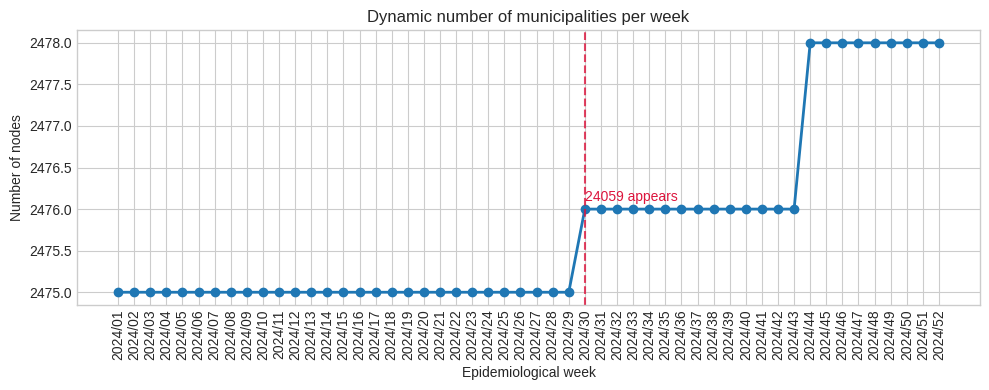

In [150]:
node_counts = pd.DataFrame({
    'week': list(graphs_window.keys()),
    'node_count': [graph.number_of_nodes() for graph in graphs_window.values()],
    'focus_node_present': [focus_node in graph for graph in graphs_window.values()],
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(node_counts['week'], node_counts['node_count'], marker='o', linewidth=2)
ax.set_title('Dynamic number of municipalities per week')
ax.set_xlabel('Epidemiological week')
ax.set_ylabel('Number of nodes')
ax.tick_params(axis='x', rotation=90)

for _, row in node_counts[node_counts['focus_node_present']].head(1).iterrows():
    ax.axvline(row['week'], color='crimson', linestyle='--', alpha=0.8)
    ax.text(row['week'], row['node_count'] + 0.1, f'{focus_node} appears', color='crimson')

plt.tight_layout()
node_counts

## 10. Visualize Node-Level Time Series

Here we track one municipality through time using node attributes stored in the weekly graphs.

,week,mortality_rate,temperature,precipitation,humidity,10m_wind_speed
0,2024/01,2.522193,13.536460,0.106811,42.990921,2.479060
1,2024/02,2.851174,14.829295,0.303269,40.399708,3.619540
2,2024/03,3.070495,14.435848,0.284433,42.686328,1.915458
3,2024/04,1.754569,15.598373,1.512765,49.905910,2.496404
4,2024/05,1.754569,14.341186,0.739812,51.272711,2.805371
5,2024/06,1.315927,15.936114,0.013351,28.811051,2.486276
6,2024/07,1.864229,13.720034,29.290915,59.839494,2.141174
7,2024/08,1.425587,15.574151,0.222206,42.141201,1.374321
8,2024/09,1.206266,19.435122,0.802756,30.875004,1.271516
9,2024/10,0.986945,19.699158,0.133752,23.433395,2.921265


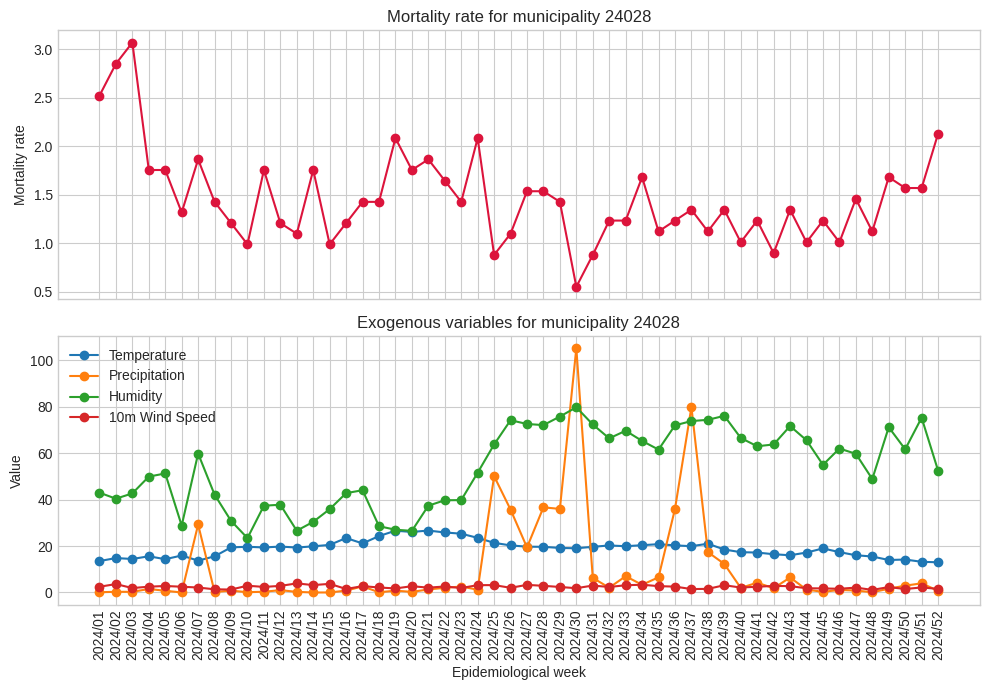

In [151]:
time_series = []

for week, graph in graphs_window.items():
    if stable_node not in graph:
        continue
    attrs = graph.nodes[stable_node]
    time_series.append({
        'week': week,
        'mortality_rate': attrs['mortality_rate'],
        'temperature': attrs['2m_mean_temperature'],
        'precipitation': attrs['total_precipitation'],
        'humidity': attrs['2m_relative_humidity'],
        '10m_wind_speed': attrs['10m_wind_speed'],
    })

time_series_df = pd.DataFrame(time_series)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(time_series_df['week'], time_series_df['mortality_rate'], marker='o', color='crimson')
axes[0].set_title(f'Mortality rate for municipality {stable_node}')
axes[0].set_ylabel('Mortality rate')

axes[1].plot(time_series_df['week'], time_series_df['temperature'], marker='o', label='Temperature')
axes[1].plot(time_series_df['week'], time_series_df['precipitation'], marker='o', label='Precipitation')
axes[1].plot(time_series_df['week'], time_series_df['humidity'], marker='o', label='Humidity')
axes[1].plot(time_series_df['week'], time_series_df['10m_wind_speed'], marker='o', label='10m Wind Speed')
axes[1].set_title(f'Exogenous variables for municipality {stable_node}')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Epidemiological week')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
time_series_df

## 11. Visualize A Local Network On The Map\n
\n
We can visualize a one-hop ego network using municipality longitude/latitude as node positions. Node color is mapped to mortality rate and node size to population.

,node,name,longitude,latitude,mortality_rate,population
8,24028,San Luis Potosí/San Luis Potosí,-100.975962,22.288967,1.680508,911908
9,24035,San Luis Potosí/Soledad de Graciano Sánchez,-100.855172,22.271591,1.204558,332072
0,24056,San Luis Potosí/Villa de Arista,-100.804397,22.659907,0.000000,17258
2,24021,San Luis Potosí/Mexquitic de Carmona,-101.156731,22.259028,0.000000,58469
1,24051,San Luis Potosí/Villa Hidalgo,-100.673379,22.640506,0.000000,15458
3,24046,San Luis Potosí/Villa de Arriaga,-101.273190,21.968585,0.000000,18206
4,24050,San Luis Potosí/Villa de Reyes,-100.981536,21.851761,0.000000,52912
6,24022,San Luis Potosí/Moctezuma,-101.171020,22.733382,0.000000,19036
5,24059,San Luis Potosí/Villa de Pozos,-100.825283,22.100874,0.000000,148165
7,24055,San Luis Potosí/Zaragoza,-100.676719,22.008159,0.000000,27386


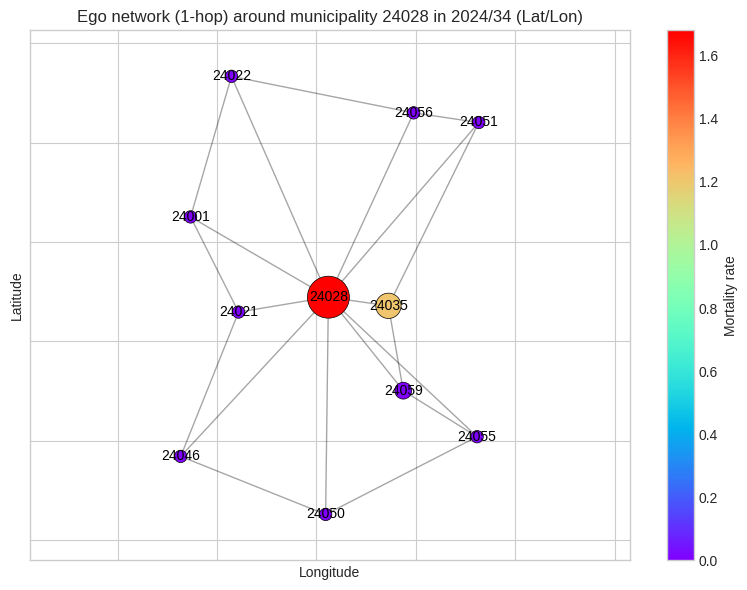

In [152]:
center_node = stable_node
ego = nx.ego_graph(G, center_node, radius=1)

# Use true geographic coordinates for plotting (x=longitude, y=latitude).
positions = {
    node: (ego.nodes[node]['longitude'], ego.nodes[node]['latitude'])
    for node in ego.nodes()
}
node_colors = [ego.nodes[node]['mortality_rate'] for node in ego.nodes()]
node_sizes = [max(80, ego.nodes[node]['population'] / 1000) for node in ego.nodes()]
labels = {node: node for node in ego.nodes()}

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(ego, positions, alpha=0.35, ax=ax)
nodes = nx.draw_networkx_nodes(
    ego,
    positions,
    node_color=node_colors,
    node_size=node_sizes,
    cmap='rainbow',
    edgecolors='black',
    linewidths=0.5,
    ax=ax,
)
nx.draw_networkx_labels(ego, positions, labels=labels, font_size=10, ax=ax)

ax.set_title(f'Ego network (1-hop) around municipality {center_node} in {focus_week} (Lat/Lon)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal', adjustable='datalim')

cbar = plt.colorbar(nodes, ax=ax)
cbar.set_label('Mortality rate')
plt.tight_layout()

pd.DataFrame({
    'node': list(ego.nodes()),
    'name': [f"{ego.nodes[node]['state']}/{ego.nodes[node]['municipality']}" for node in ego.nodes()],
    'longitude': [ego.nodes[node]['longitude'] for node in ego.nodes()],
    'latitude': [ego.nodes[node]['latitude'] for node in ego.nodes()],
    'mortality_rate': [ego.nodes[node]['mortality_rate'] for node in ego.nodes()],
    'population': [ego.nodes[node]['population'] for node in ego.nodes()],
}).sort_values('mortality_rate', ascending=False)


## 12. What To Try Next

Possible next steps with this package:

- build larger time windows and study structural changes over time
- train graph-based predictive models using `X` and `edge_index`
- compare subgraphs before and after municipality creation weeks
- combine the direct tables with graph-level workflows for custom analyses
